In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import joblib

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix , auc, precision_recall_curve, roc_auc_score, balanced_accuracy_score
from scipy.stats import uniform, randint
from sklearn.model_selection import ParameterGrid, cross_validate
import matplotlib.pyplot as plt

In [2]:
dataset_gold = pd.read_csv('../../assets/gold/experimentos_finales/dataset_final.csv')

In [3]:
max_arboles = [5, 10, 15, 20]
metricas = ["gini", "entropy"]
bootstrap = [True]
max_depth = [3]
min_samples_split= [2]
min_samples_leaf = [1]
max_features = ['sqrt']


def crear_grilla(max_arboles, metricas, bootstrap, min_samples_split, min_samples_leaf, max_features):
    parametros = {
        'n_estimators': max_arboles,
        'criterion': metricas,
        'bootstrap': bootstrap,
        'max_depth': max_depth,
        'min_samples_split': min_samples_split,
        'min_samples_leaf': min_samples_leaf,
        'max_features': max_features
    }
    grilla = list(ParameterGrid(parametros))
    return grilla

grilla_parametros = crear_grilla(max_arboles, metricas, bootstrap,min_samples_split, min_samples_leaf, max_features)
grilla_parametros

[{'bootstrap': True,
  'criterion': 'gini',
  'max_depth': 3,
  'max_features': 'sqrt',
  'min_samples_leaf': 1,
  'min_samples_split': 2,
  'n_estimators': 5},
 {'bootstrap': True,
  'criterion': 'gini',
  'max_depth': 3,
  'max_features': 'sqrt',
  'min_samples_leaf': 1,
  'min_samples_split': 2,
  'n_estimators': 10},
 {'bootstrap': True,
  'criterion': 'gini',
  'max_depth': 3,
  'max_features': 'sqrt',
  'min_samples_leaf': 1,
  'min_samples_split': 2,
  'n_estimators': 15},
 {'bootstrap': True,
  'criterion': 'gini',
  'max_depth': 3,
  'max_features': 'sqrt',
  'min_samples_leaf': 1,
  'min_samples_split': 2,
  'n_estimators': 20},
 {'bootstrap': True,
  'criterion': 'entropy',
  'max_depth': 3,
  'max_features': 'sqrt',
  'min_samples_leaf': 1,
  'min_samples_split': 2,
  'n_estimators': 5},
 {'bootstrap': True,
  'criterion': 'entropy',
  'max_depth': 3,
  'max_features': 'sqrt',
  'min_samples_leaf': 1,
  'min_samples_split': 2,
  'n_estimators': 10},
 {'bootstrap': True,
  '

## Explicabilidad

Hacemos el experimento 2 pero ahora con variables "blandas". Esto permite a los actores del FCEN, por ejemplo +Acompañamiento, a enfocar sus esfuerzos en dichas variables.

In [4]:
variables_blandas = ['sexo', 'año_inscripcion_facultad', 'edad_inscripcion', 'target',
       'cohorte', 'tiempo_de_viaje', 'tiempo_desde_cbc',
       'carrera_encoded', 'nivel_estudio_madre_encoded',
       'nivel_estudio_padre_encoded', 'situacion_laboral_encoded']

In [5]:
dataset_gold_variables_blandas = dataset_gold[variables_blandas]
dataset_gold_variables_blandas.isna().sum()

sexo                             0
año_inscripcion_facultad         0
edad_inscripcion                 2
target                           0
cohorte                          0
tiempo_de_viaje                196
tiempo_desde_cbc                 0
carrera_encoded                  0
nivel_estudio_madre_encoded    445
nivel_estudio_padre_encoded    521
situacion_laboral_encoded       19
dtype: int64

In [6]:
resultados = []
importancias_resultados = []

for params in grilla_parametros:
    accuracy_scores_train = []
    accuracy_scores_test = []
    balanced_accuracy_scores_train = []
    balanced_accuracy_scores_test = []
    auc_scores_train = []
    auc_scores_test = []
    importancias_atributos = []
    print(f"Evaluando parámetros: {params}")
    # Repetir el proceso 5 veces para obtener diferentes splits de entrenamiento y test
    for i in range(5):
        # 1. Separar un 20% random como test, el random state cambia en cada iteracion, entonces da un 20% distinto en cada una
        X_train_base, X_test, y_train_base, y_test = train_test_split(dataset_gold_variables_blandas[dataset_gold_variables_blandas.columns.difference(['target'])],
                                                                        dataset_gold_variables_blandas['target'], test_size=0.2, random_state=i,
                                                                        stratify=dataset_gold_variables_blandas['target'])
        
        modelo = RandomForestClassifier(random_state=42, **params)
        modelo.fit(X_train_base, y_train_base)

        # Guardar importancia de atributos
        importancias = modelo.feature_importances_
        importancias_atributos.append(importancias)
        
        # Predicciones de clase
        y_train_pred = modelo.predict(X_train_base)
        y_validation_pred = modelo.predict(X_test)

        # Predicciones de probabilidad para AUC ROC (para la clase positiva)
        y_train_proba = modelo.predict_proba(X_train_base)[:, 1]
        y_validation_proba = modelo.predict_proba(X_test)[:, 1]

        # Accuracy
        acc_train = accuracy_score(y_train_base, y_train_pred)
        acc_test = accuracy_score(y_test, y_validation_pred)
        accuracy_scores_train.append(acc_train)
        accuracy_scores_test.append(acc_test)

        # Balanced Accuracy
        bal_acc_train = balanced_accuracy_score(y_train_base, y_train_pred)
        bal_acc_test = balanced_accuracy_score(y_test, y_validation_pred)
        balanced_accuracy_scores_train.append(bal_acc_train)
        balanced_accuracy_scores_test.append(bal_acc_test)

        # AUC ROC
        auc_train = roc_auc_score(y_train_base, y_train_proba)
        auc_test = roc_auc_score(y_test, y_validation_proba)
        auc_scores_train.append(auc_train)
        auc_scores_test.append(auc_test)
    
    # Calcular promedios y desviaciones estándar
    accuracy_train_mean = np.mean(accuracy_scores_train)
    accuracy_test_mean = np.mean(accuracy_scores_test)
    accuracy_train_std = np.std(accuracy_scores_train)
    accuracy_test_std = np.std(accuracy_scores_test)
    bal_accuracy_train_mean = np.mean(balanced_accuracy_scores_train)
    bal_accuracy_test_mean = np.mean(balanced_accuracy_scores_test)
    bal_accuracy_train_std = np.std(balanced_accuracy_scores_train)
    bal_accuracy_test_std = np.std(balanced_accuracy_scores_test)
    auc_train_mean = np.mean(auc_scores_train)
    auc_test_mean = np.mean(auc_scores_test)
    auc_train_std = np.std(auc_scores_train)
    auc_test_std = np.std(auc_scores_test)
    print(f"Resultados para {params}:")

    resultados.append({
        'params': params,
        'bootstrap': params['bootstrap'],
        'criterion': params['criterion'],
        'n_estimators': params['n_estimators'],
        'train_accuracy_mean': accuracy_train_mean,
        'test_accuracy_mean': accuracy_test_mean,
        'train_accuracy_std': accuracy_train_std,
        'test_accuracy_std': accuracy_test_std,
        'train_balanced_accuracy_mean': bal_accuracy_train_mean,
        'test_balanced_accuracy_mean': bal_accuracy_test_mean,
        'train_balanced_accuracy_std': bal_accuracy_train_std,
        'test_balanced_accuracy_std': bal_accuracy_test_std,
        'train_auc_mean': auc_train_mean,
        'test_auc_mean': auc_test_mean,
        'train_auc_std': auc_train_std,
        'test_auc_std': auc_test_std
    })

    # Calcular importancia promedio y std
    importancias_array = np.array(importancias_atributos)
    importancia_media = np.mean(importancias_array, axis=0)
    importancia_std = np.std(importancias_array, axis=0)

    # Asignar nombres de columnas
    columnas = dataset_gold_variables_blandas.columns.difference(['target'])
    # Crear dict plano para el DataFrame de importancias
    importancia_flat = {
        f"mean_{col}": importancia_media[idx]
        for idx, col in enumerate(columnas)
    }
    importancia_flat.update({
        f"std_{col}": importancia_std[idx]
        for idx, col in enumerate(columnas)
    })
    importancia_flat.update(params)  # Podés incluir los hiperparámetros para referencia

    importancias_resultados.append(importancia_flat)

Evaluando parámetros: {'bootstrap': True, 'criterion': 'gini', 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 5}
Resultados para {'bootstrap': True, 'criterion': 'gini', 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 5}:
Evaluando parámetros: {'bootstrap': True, 'criterion': 'gini', 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 10}
Resultados para {'bootstrap': True, 'criterion': 'gini', 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 10}:
Evaluando parámetros: {'bootstrap': True, 'criterion': 'gini', 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 15}
Resultados para {'bootstrap': True, 'criterion': 'gini', 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 15

In [7]:
resultados = pd.DataFrame(resultados)
resultados

,params,bootstrap,criterion,n_estimators,train_accuracy_mean,test_accuracy_mean,train_accuracy_std,test_accuracy_std,train_balanced_accuracy_mean,test_balanced_accuracy_mean,train_balanced_accuracy_std,test_balanced_accuracy_std,train_auc_mean,test_auc_mean,train_auc_std,test_auc_std
0,"{'bootstrap': True, 'criterion': 'gini', 'max_...",True,gini,5,0.669884,0.662042,0.004787,0.032301,0.657299,0.649642,0.004245,0.034289,0.729557,0.711313,0.002519,0.041526
1,"{'bootstrap': True, 'criterion': 'gini', 'max_...",True,gini,10,0.675965,0.668593,0.005067,0.034703,0.663532,0.656283,0.005314,0.037213,0.731425,0.718764,0.004281,0.038016
2,"{'bootstrap': True, 'criterion': 'gini', 'max_...",True,gini,15,0.674324,0.672062,0.005523,0.029884,0.662301,0.660307,0.005571,0.031695,0.732393,0.718454,0.004513,0.036282
3,"{'bootstrap': True, 'criterion': 'gini', 'max_...",True,gini,20,0.678282,0.669364,0.005852,0.031321,0.666717,0.658749,0.006401,0.033156,0.734030,0.719984,0.005268,0.035545
4,"{'bootstrap': True, 'criterion': 'entropy', 'm...",True,entropy,5,0.670174,0.663584,0.004419,0.030843,0.657510,0.651619,0.005401,0.033908,0.729984,0.713538,0.002808,0.043507
5,"{'bootstrap': True, 'criterion': 'entropy', 'm...",True,entropy,10,0.674517,0.670906,0.006884,0.038946,0.662135,0.659177,0.006587,0.041256,0.732084,0.719566,0.004935,0.037169
6,"{'bootstrap': True, 'criterion': 'entropy', 'm...",True,entropy,15,0.676158,0.669750,0.005966,0.027536,0.664052,0.657906,0.006352,0.028893,0.732947,0.719039,0.005081,0.036183
7,"{'bootstrap': True, 'criterion': 'entropy', 'm...",True,entropy,20,0.678185,0.671676,0.007838,0.027046,0.666936,0.660587,0.007795,0.029089,0.734435,0.720953,0.005720,0.034509


In [8]:
resultados.to_csv('../../assets/resultados_modelos/experimento_variables_blandas/resultados_modelos.csv', index=False)

In [9]:
df_importancias = pd.DataFrame(importancias_resultados)
df_importancias

,mean_año_inscripcion_facultad,mean_carrera_encoded,mean_cohorte,mean_edad_inscripcion,mean_nivel_estudio_madre_encoded,mean_nivel_estudio_padre_encoded,mean_sexo,mean_situacion_laboral_encoded,mean_tiempo_de_viaje,mean_tiempo_desde_cbc,...,std_situacion_laboral_encoded,std_tiempo_de_viaje,std_tiempo_desde_cbc,bootstrap,criterion,max_depth,max_features,min_samples_leaf,min_samples_split,n_estimators
0,0.009262,0.021834,0.022384,0.461441,0.069076,0.100901,0.009678,0.223612,0.023601,0.058212,...,0.015449,0.013047,0.037615,True,gini,3,sqrt,1,2,5
1,0.010425,0.016838,0.018450,0.450448,0.074917,0.085107,0.006879,0.207428,0.023167,0.106340,...,0.026519,0.007428,0.027408,True,gini,3,sqrt,1,2,10
2,0.016667,0.018144,0.022102,0.374623,0.069831,0.103729,0.006312,0.234434,0.030001,0.124156,...,0.024103,0.003511,0.025975,True,gini,3,sqrt,1,2,15
3,0.017742,0.016797,0.018214,0.392864,0.089869,0.092816,0.006291,0.203324,0.027545,0.134538,...,0.021028,0.002778,0.023724,True,gini,3,sqrt,1,2,20
4,0.015438,0.017190,0.021727,0.454494,0.072518,0.098937,0.007546,0.217038,0.032050,0.063061,...,0.027022,0.011844,0.029198,True,entropy,3,sqrt,1,2,5
5,0.013422,0.015054,0.017869,0.446228,0.077084,0.085193,0.005841,0.203089,0.028669,0.107550,...,0.026548,0.009021,0.021260,True,entropy,3,sqrt,1,2,10
6,0.019713,0.018597,0.020620,0.372577,0.071577,0.103257,0.005685,0.229432,0.033583,0.124959,...,0.023200,0.004381,0.022004,True,entropy,3,sqrt,1,2,15
7,0.020298,0.016868,0.016996,0.395065,0.089210,0.091860,0.005756,0.196858,0.031111,0.135978,...,0.021701,0.005696,0.017507,True,entropy,3,sqrt,1,2,20


In [10]:
#veo las columnas que empiezan con mean
mean_columns = [col for col in df_importancias.columns if col.startswith('mean_')]
df_importancias[mean_columns]

,mean_año_inscripcion_facultad,mean_carrera_encoded,mean_cohorte,mean_edad_inscripcion,mean_nivel_estudio_madre_encoded,mean_nivel_estudio_padre_encoded,mean_sexo,mean_situacion_laboral_encoded,mean_tiempo_de_viaje,mean_tiempo_desde_cbc
0,0.009262,0.021834,0.022384,0.461441,0.069076,0.100901,0.009678,0.223612,0.023601,0.058212
1,0.010425,0.016838,0.018450,0.450448,0.074917,0.085107,0.006879,0.207428,0.023167,0.106340
2,0.016667,0.018144,0.022102,0.374623,0.069831,0.103729,0.006312,0.234434,0.030001,0.124156
3,0.017742,0.016797,0.018214,0.392864,0.089869,0.092816,0.006291,0.203324,0.027545,0.134538
4,0.015438,0.017190,0.021727,0.454494,0.072518,0.098937,0.007546,0.217038,0.032050,0.063061
5,0.013422,0.015054,0.017869,0.446228,0.077084,0.085193,0.005841,0.203089,0.028669,0.107550
6,0.019713,0.018597,0.020620,0.372577,0.071577,0.103257,0.005685,0.229432,0.033583,0.124959
7,0.020298,0.016868,0.016996,0.395065,0.089210,0.091860,0.005756,0.196858,0.031111,0.135978


In [11]:
df_importancias.to_csv('../../assets/resultados_modelos/experimento_variables_blandas/importancias_atributos.csv', index=False)

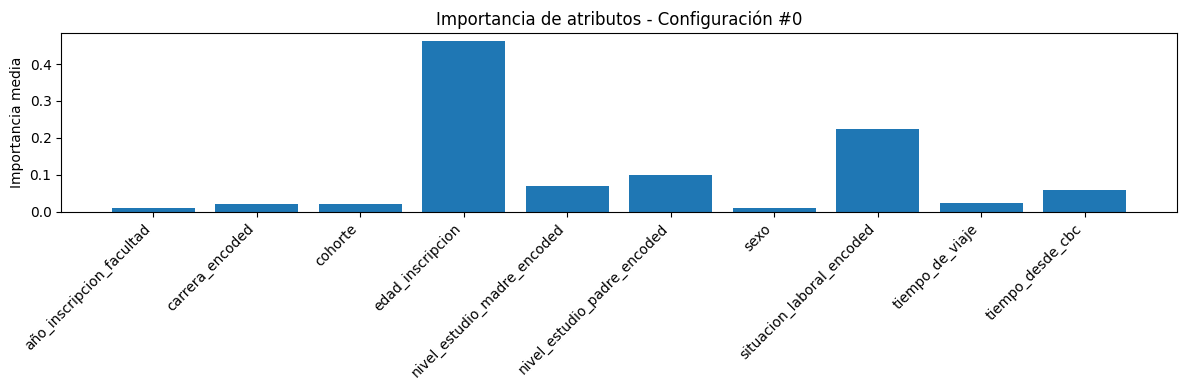

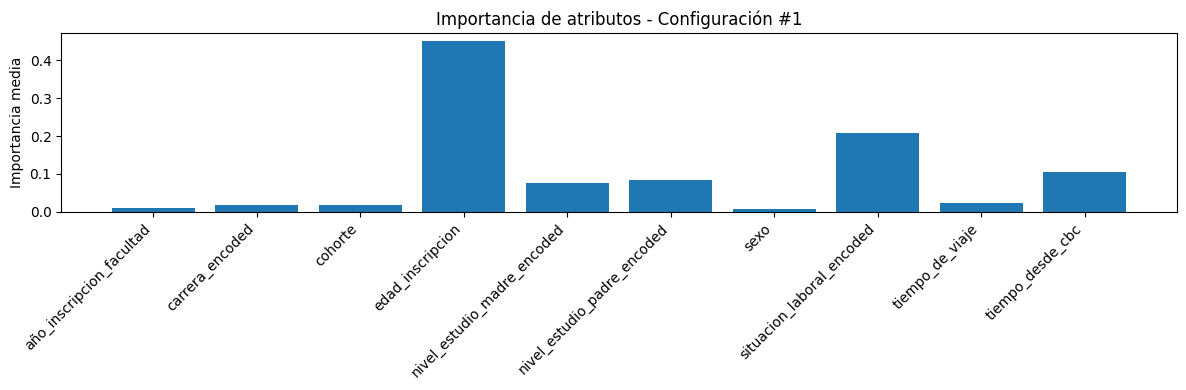

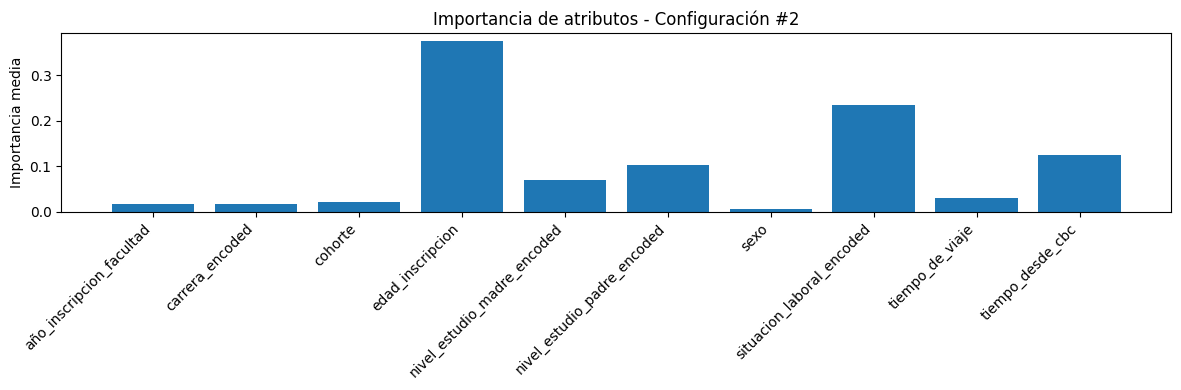

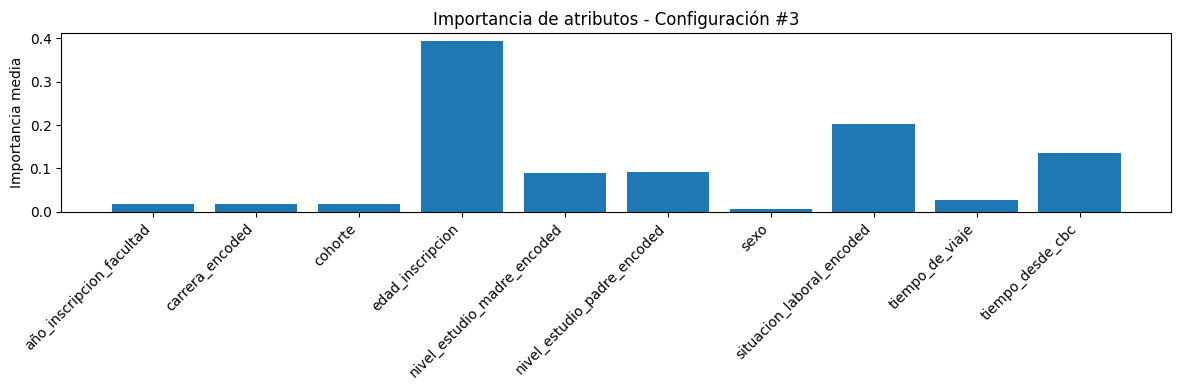

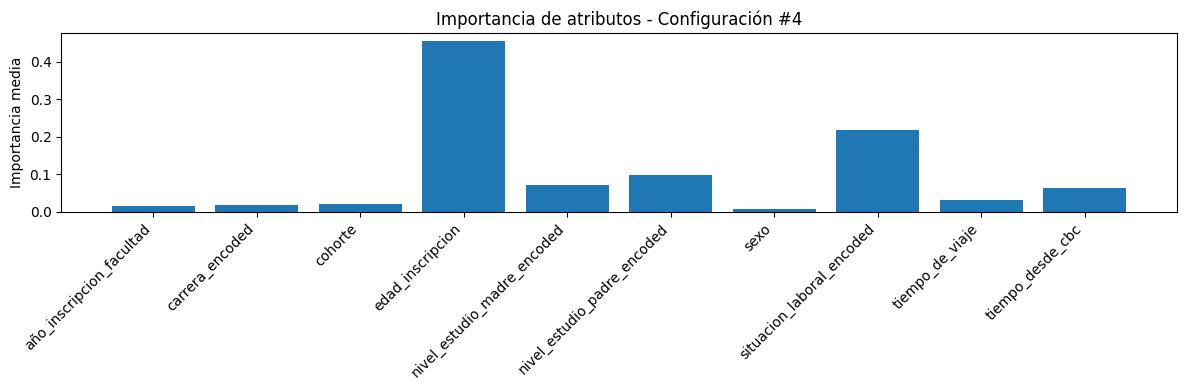

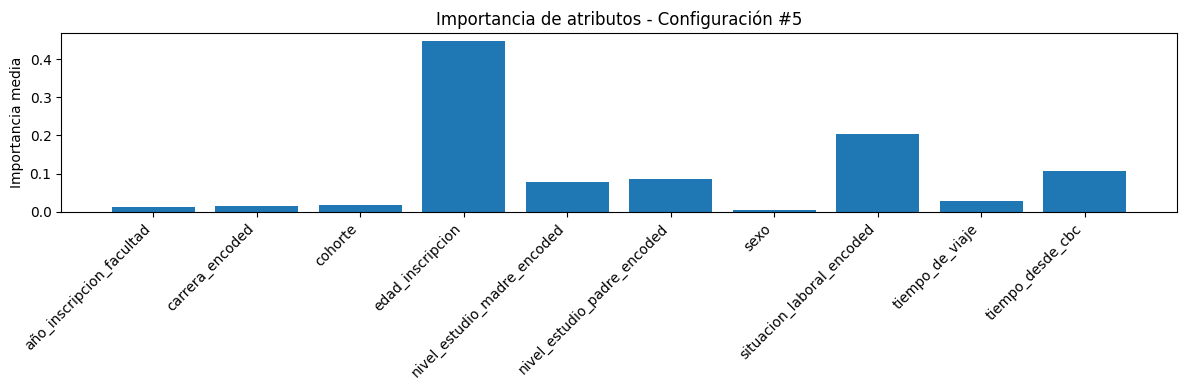

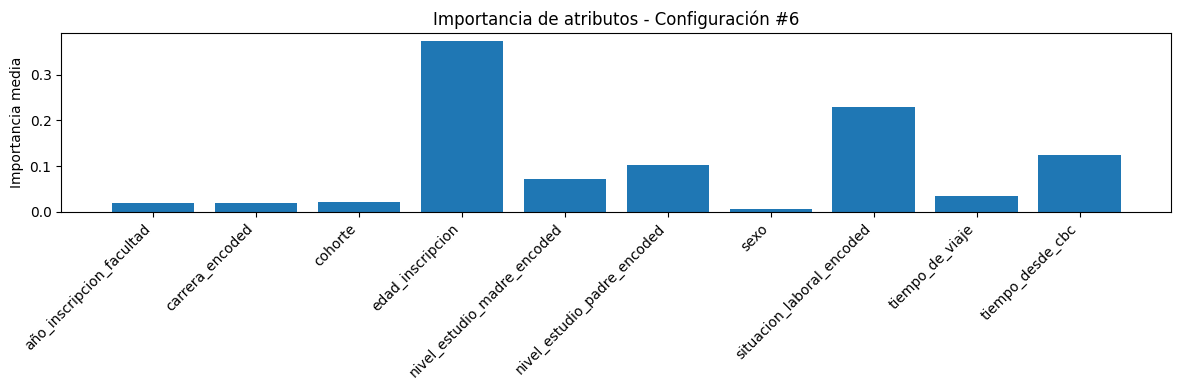

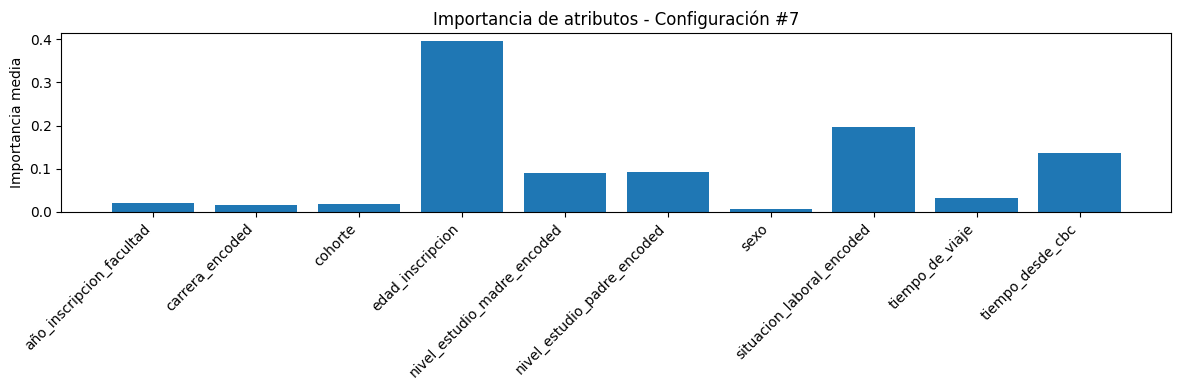

In [12]:
mean_columns = [col for col in df_importancias.columns if col.startswith('mean_')]

for idx, row in df_importancias.iterrows():
    importancias = row[mean_columns]
    columnas = [col.replace("mean_", "") for col in mean_columns]
    
    plt.figure(figsize=(12, 4))
    plt.bar(columnas, importancias)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Importancia media")
    plt.title(f"Importancia de atributos - Configuración #{idx}")
    plt.tight_layout()
    plt.show()

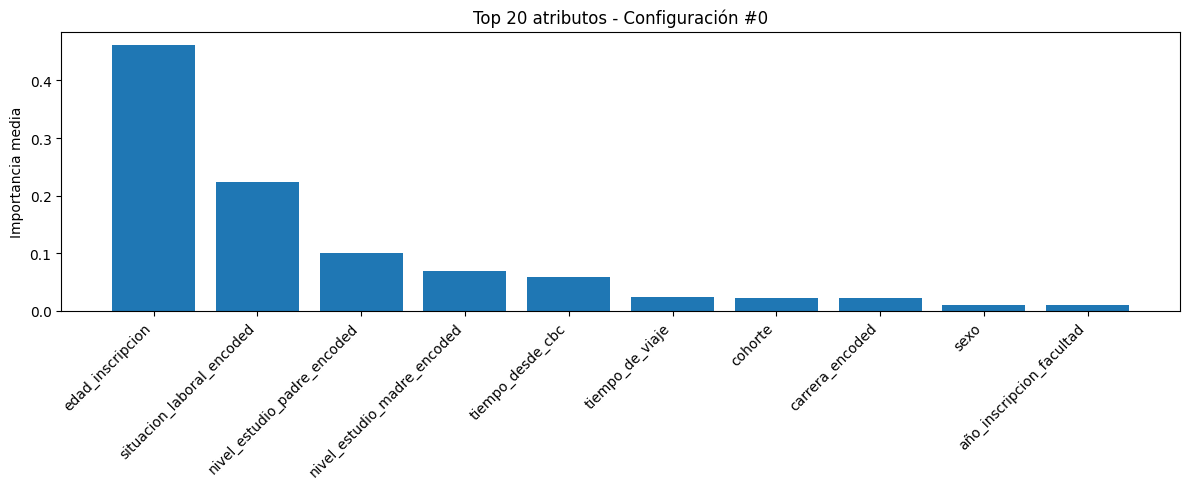

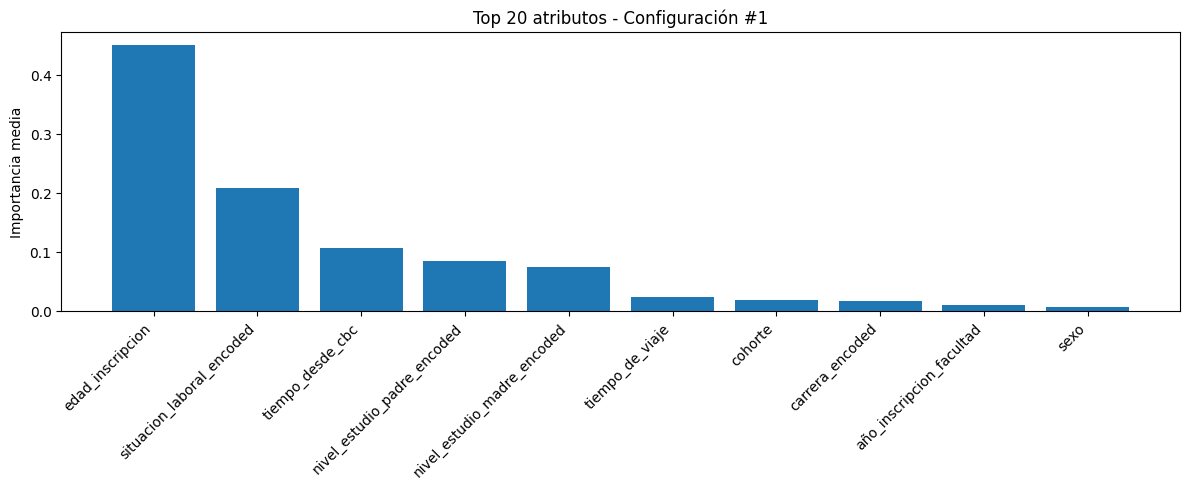

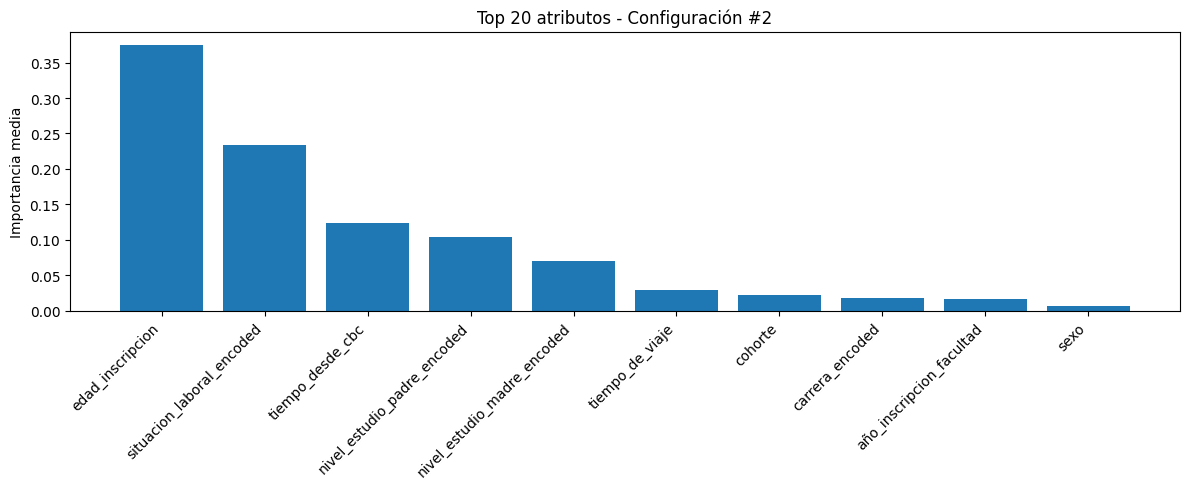

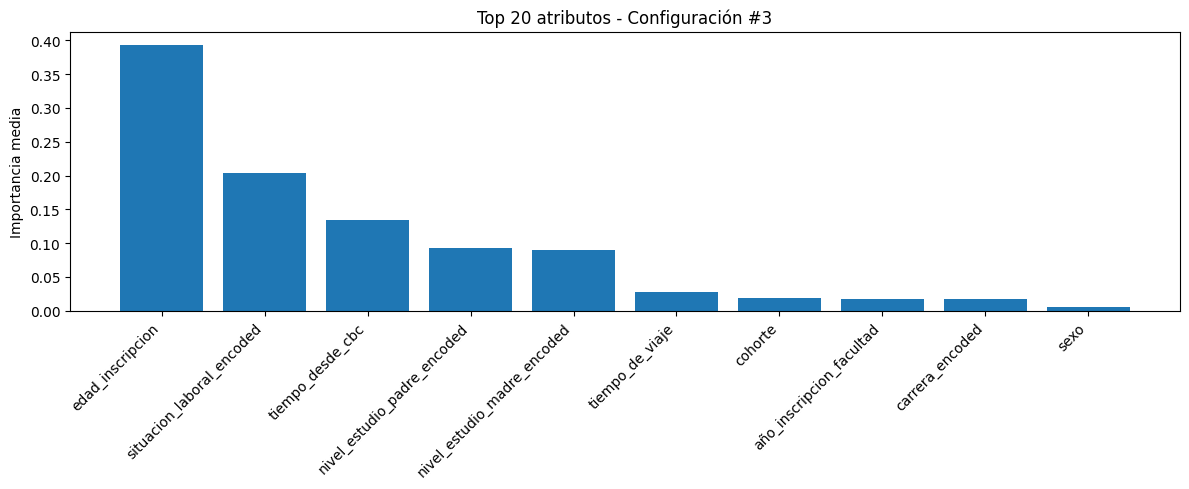

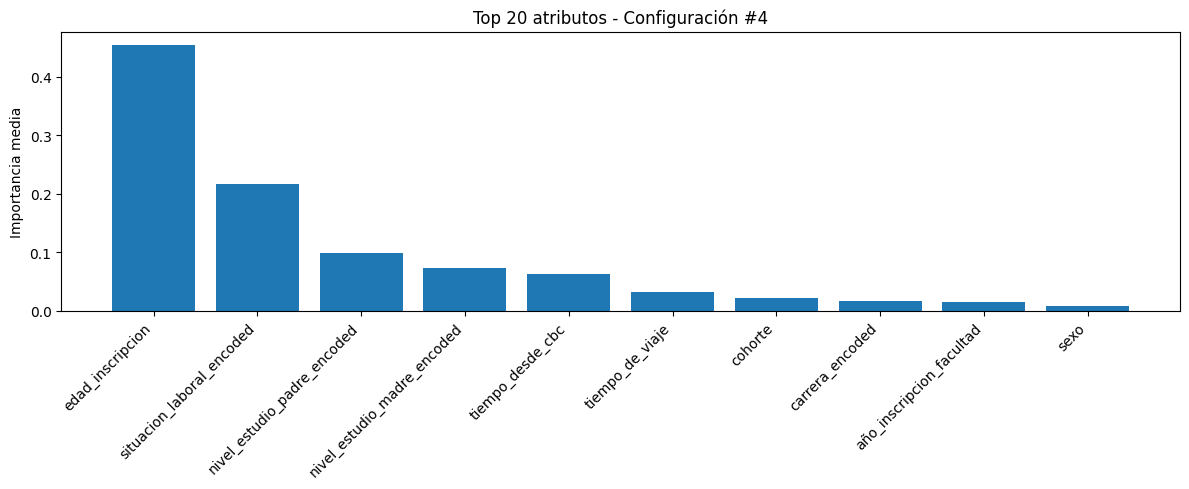

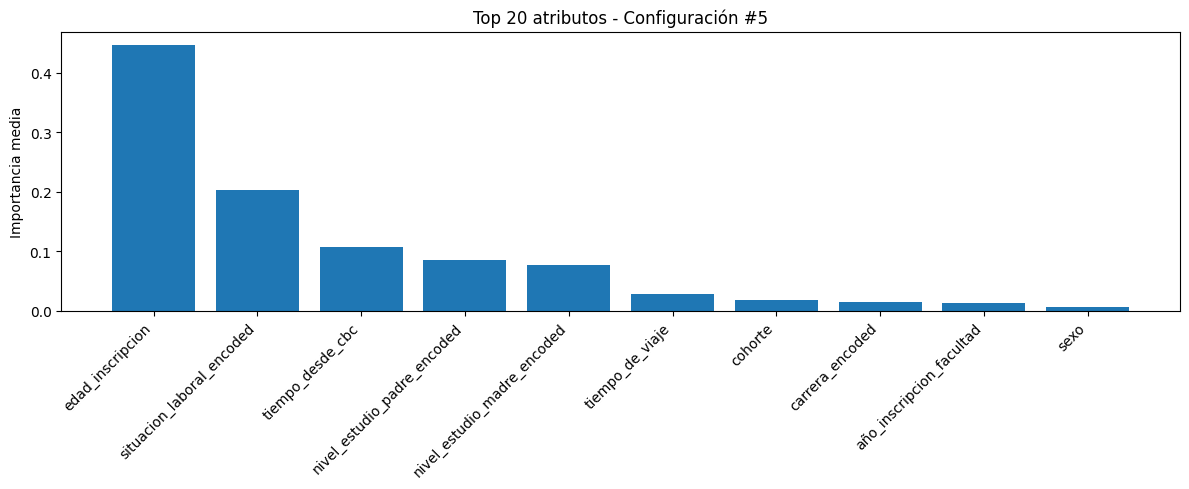

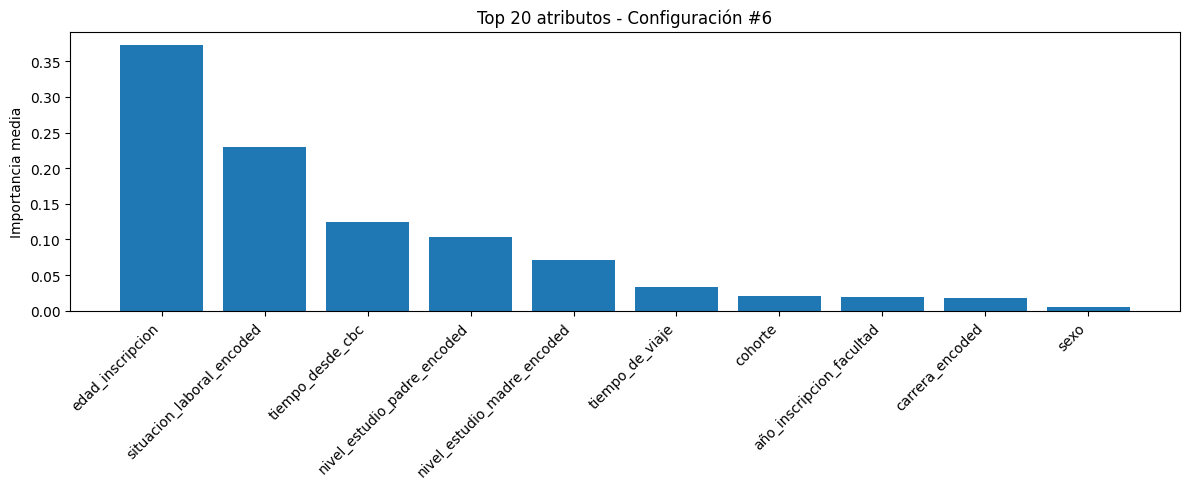

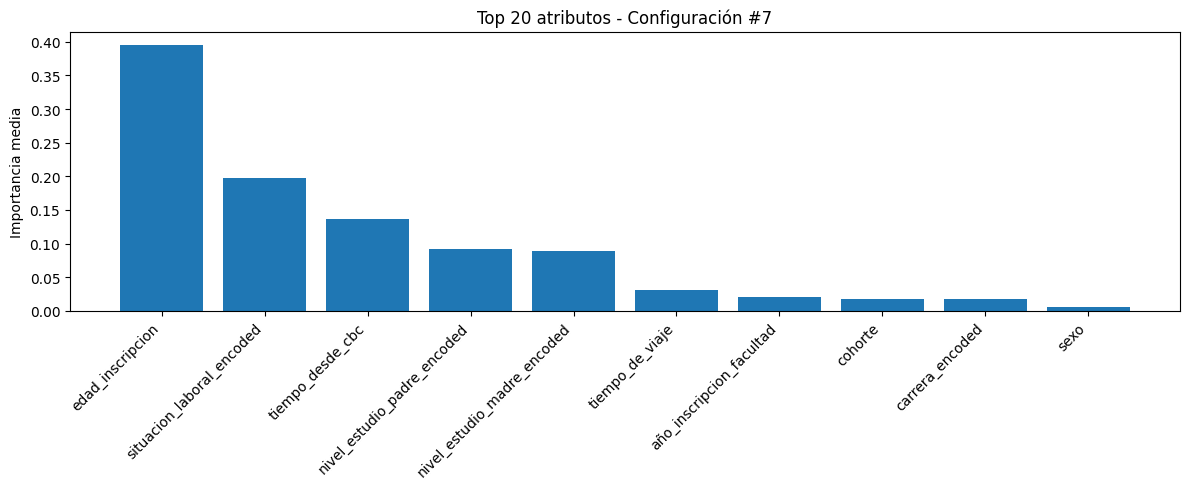

In [14]:
mean_columns = [col for col in df_importancias.columns if col.startswith('mean_')]

for idx, row in df_importancias.iterrows():
    importancias = row[mean_columns]
    
    # Ordenar y quedarse con el top 20
    top_importancias = importancias.sort_values(ascending=False).head(20)
    columnas_top = [col.replace("mean_", "") for col in top_importancias.index]

    # Plot
    plt.figure(figsize=(12, 5))
    plt.bar(columnas_top, top_importancias.values)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Importancia media")
    plt.title(f"Top 20 atributos - Configuración #{idx}")
    plt.tight_layout()
    plt.savefig(f'../../assets/resultados_modelos/experimento_variables_blandas/importancia_atributos_random_forest_con_boostrap_{idx}_top_20.png')
    plt.show()